## Dataset Structure

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import numpy as np
from collections import Counter, defaultdict
import hashlib

dataset_path = "C:\\Users\\PC\\WX\\dataset"

# Count images in each class
def count_images(folder):
    return len(os.listdir(folder)) if os.path.exists(folder) else 0

# Check for train, validation, test sets
data_splits = ["Train", "Validation", "Test"]
class_counts = {}

for split in data_splits:
    real_count = count_images(os.path.join(dataset_path, split, "real"))
    fake_count = count_images(os.path.join(dataset_path, split, "fake"))
    class_counts[split] = {"Real": real_count, "Fake": fake_count}

# Print results
for split, counts in class_counts.items():
    print(f"{split.upper()} Set - Real: {counts['Real']} | Fake: {counts['Fake']}")



TRAIN Set - Real: 70001 | Fake: 70001
VALIDATION Set - Real: 19787 | Fake: 19641
TEST Set - Real: 5413 | Fake: 5492


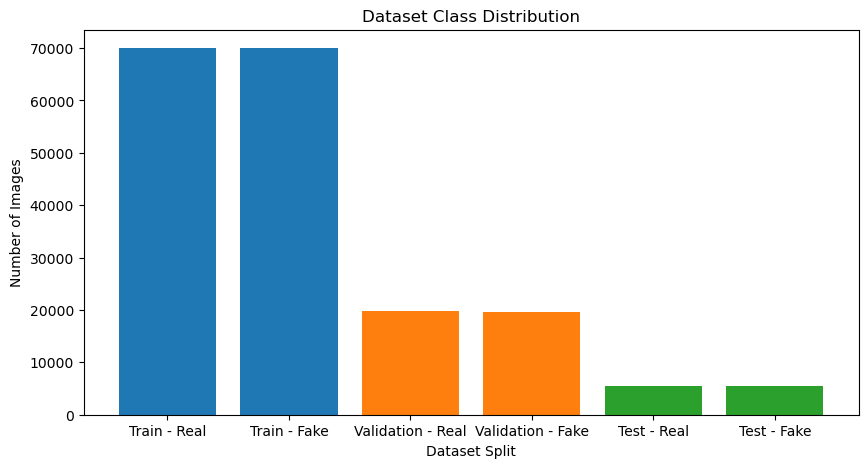

In [ ]:
# Plot the class distribution
plt.figure(figsize=(10, 5))
for split, counts in class_counts.items():
    plt.bar([f"{split} - Real", f"{split} - Fake"], [counts["Real"], counts["Fake"]])
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.title("Dataset Class Distribution")
plt.show()

- The figure shows the balanced distribution of real and fake images across the training, validation, and test datasets. The number of real and fake images is nearly equal in each dataset split, ensuring that the model is trained and evaluated on a well-balanced dataset, which helps improve its ability to accurately classify both real and fake images.


## Sample image (real vs fake)

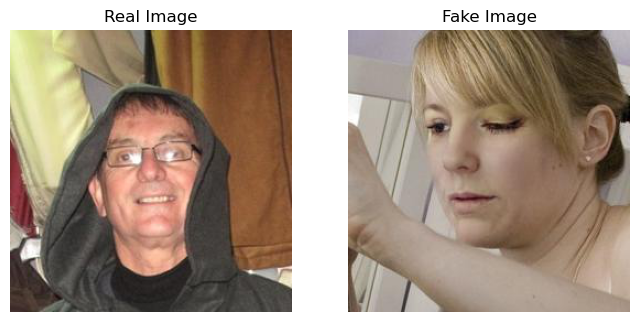

In [ ]:
# Define sample image paths (Change these to actual images in your dataset)
real_image_path = "C:\\Users\\PC\\WX\\dataset\\train\\real\\real_0.jpg"
fake_image_path = "C:\\Users\\PC\\WX\\dataset\\train\\fake\\fake_0.jpg"

# Load and display images
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for ax, img_path, label in zip(axes, [real_image_path, fake_image_path], ["Real", "Fake"]):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"{label} Image")
    ax.axis("off")

plt.show()


## Image Size 

In [ ]:
image_sizes = []

# Loop through real and fake images to get their sizes
for label in ["real", "fake"]:
    folder_path = os.path.join(dataset_path, "train", label)
    for filename in os.listdir(folder_path):
        img = cv2.imread(os.path.join(folder_path, filename))
        if img is not None:
            image_sizes.append(img.shape[:2])  # (Height, Width)

# Count occurrences of each image size
size_counts = Counter(image_sizes)

# Display unique image sizes and their counts
print("Unique Image Sizes in Dataset:")
for size, count in size_counts.items():
    print(f"Size: {size[0]}x{size[1]} - {count} images")



Unique Image Sizes in Dataset:
Size: 256x256 - 140002 images


## Check duplicate image

In [ ]:
# Function to compute MD5 hash of an image file
def md5_hash(image_path):
    """Compute the MD5 hash of an image file to detect duplicates."""
    with open(image_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

# Define dataset path
dataset_path = "C:\\Users\\PC\\WX\\dataset"

# Dictionary to store duplicate counts for each dataset and class
duplicate_counts = defaultdict(lambda: {"real": 0, "fake": 0})

# Store all hashes
hashes = {}
duplicates = []

for split in ["train", "validation", "test"]:  # Include all datasets
    for label in ["real", "fake"]:  
        folder_path = os.path.join(dataset_path, split, label)
        if not os.path.exists(folder_path):  # Skip if the folder does not exist
            continue

        for filename in os.listdir(folder_path):
            img_path = os.path.join(folder_path, filename)
            img_hash = md5_hash(img_path)

            if img_hash in hashes:
                duplicates.append(img_path)
                duplicate_counts[split][label] += 1  # Count duplicate in respective dataset/class
            else:
                hashes[img_hash] = img_path

print(f" Found {len(duplicates)} duplicate images across all datasets.\n")

for split in ["train", "validation", "test"]:
    print(f" {split.capitalize()} Dataset:")
    print(f"  - Real Duplicates: {duplicate_counts[split]['real']}")
    print(f"  - Fake Duplicates: {duplicate_counts[split]['fake']}\n")




 Found 17135 duplicate images across all datasets.

 Train Dataset:
  - Real Duplicates: 11412
  - Fake Duplicates: 5

 Validation Dataset:
  - Real Duplicates: 5718
  - Fake Duplicates: 0

 Test Dataset:
  - Real Duplicates: 0
  - Fake Duplicates: 0



- The 17,135 duplicate images across the datasets were found to help maintain balance between real and fake images. The Train dataset contains 11,412 real duplicates and 5 fake duplicates, ensuring the model sees enough examples of real images for training. The Validation dataset has 5,718 real duplicates, while the Test dataset has no duplicates, ensuring a fair evaluation on unique data. These duplicates support dataset balance by providing additional real image examples.

## Check image quality

In [ ]:
def detect_blur(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
    laplacian_var = cv2.Laplacian(img, cv2.CV_64F).var()  # Compute variance of Laplacian
    return laplacian_var  # Lower value = more blurry

# Test on a sample image
image_path = "C:\\Users\\PC\\WX\\dataset\\train\\real\\real_0.jpg"
blur_value = detect_blur(image_path)
print(f"Blurriness Score: {blur_value}")


Blurriness Score: 241.4220234071836


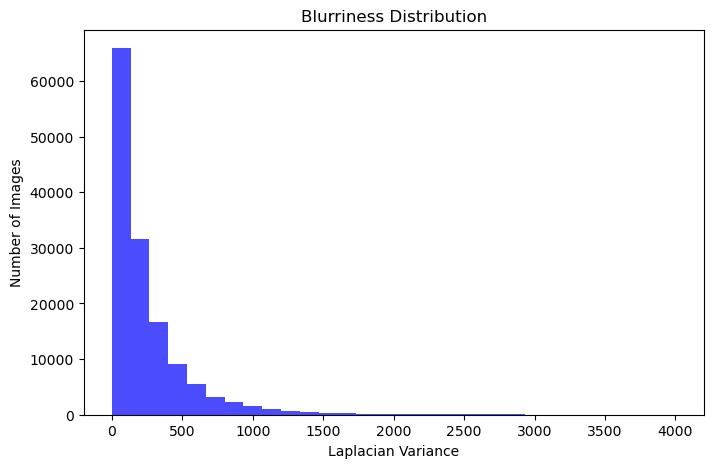

In [ ]:
# Check multiple images
blurriness_scores = []

for label in ["real", "fake"]:
    folder_path = os.path.join(dataset_path, "train", label)
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        blurriness_scores.append(detect_blur(img_path))

plt.figure(figsize=(8, 5))
plt.hist(blurriness_scores, bins=30, alpha=0.7, color="blue", range=(0, 4000))
plt.title("Blurriness Distribution")
plt.xlabel("Laplacian Variance")
plt.ylabel("Number of Images")
plt.show()

- The diagram above show that most of the images are blurry